## Logistic Regression

This notebook looks at the Logistic Regression model which is used for classification.

Using this model we will check the predictive performance and assess whether we need to further explore more parametric models.

In [1]:
%%capture
%pip install -U statsmodels

In [2]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import utils
from utils import *
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_validate
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, auc
warnings.filterwarnings(action='ignore')

In [3]:
df = pd.read_csv('../../data/ACME-HappinessSurvey2020_shrunk.csv')

df.head()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [4]:
y = df['customer satisfaction'].values
X = df.drop('customer satisfaction', axis=1)

In [5]:
seed = 5249

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=seed, shuffle=True
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((100, 6), (26, 6), (100,), (26,))

In [6]:
y_train.mean(), y_test.mean()

(np.float64(0.55), np.float64(0.5384615384615384))

## L2 Regularization (Default)

In [16]:
lr = LogisticRegression(penalty='l2', random_state=seed)

In [17]:
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print(f"Target variable mean: {y.mean()}\n")
return_scores(lr, X_train, X_test, y_train, y_test)


Target variable mean: 0.5476190476190477



,Accuracy,Recall,Precision
Train,0.630000,0.727273,0.645161
Test,0.461538,0.500000,0.500000


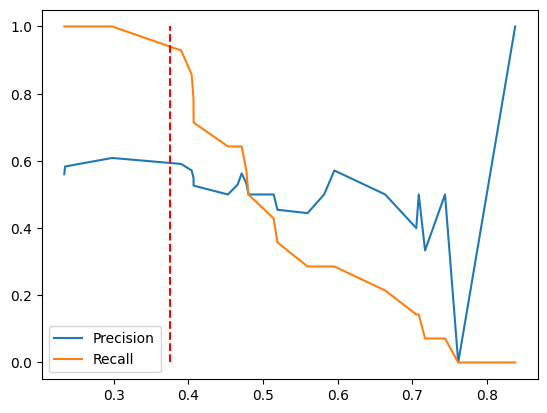

In [18]:
# TPR = TP/P ... recall and sensitivity
# FPR = 1 - TPR
# TNR = TN / N
# FNR = 1 - TNR
# precision = TP / TP+FP (PPV) - used if few positive samples and gives more critical assessment of quality  of classifier than ROC

lr_probs = lr.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, lr_probs)

plt.plot(thresholds, precision[1:], label='Precision')
plt.plot(thresholds, recall[1:], label='Recall')
plt.vlines([.375], ymin=[0.0], ymax=[1.0], linestyles='--', color='r')
plt.legend()
plt.show()

In [19]:
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

In [20]:
for i in [2,4,5,10]:
    kfold = KFold(n_splits=i, shuffle=True, random_state=seed)
    print(f'{i} folds\n')
    cv_results = cross_validate(lr,
                X_train,
                y_train,
                scoring='accuracy',
                cv=kfold,
                return_train_score=True,
                n_jobs=-1)

    print(f"Train mean: {cv_results['train_score'].mean()} || Train var.: {cv_results['train_score'].var()}")
    print(f"Test mean:  {cv_results['test_score'].mean()}  || Test var. : {cv_results['test_score'].var()}")
    print()

2 folds



Train mean: 0.68 || Train var.: 0.0
Test mean:  0.6  || Test var. : 0.0004000000000000007

4 folds

Train mean: 0.6533333333333334 || Train var.: 0.000977777777777777
Test mean:  0.5800000000000001  || Test var. : 0.001999999999999999

5 folds

Train mean: 0.6399999999999999 || Train var.: 0.00033749999999999953
Test mean:  0.55  || Test var. : 0.006999999999999999

10 folds

Train mean: 0.638888888888889 || Train var.: 0.0004753086419753082
Test mean:  0.56  || Test var. : 0.020399999999999995



In [21]:
params = {
    'C': 10**np.linspace(-3,4,25)
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=params,
    n_jobs=-1,
    cv=kfold,
    refit=False,
    scoring=['accuracy', 'recall'],
    return_train_score=True
)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
             estimator=LogisticRegression(random_state=5249), n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 1.95734178e-03, 3.83118685e-03, 7.49894209e-03,
       1.46779927e-02, 2.87298483e-02, 5.62341325e-02, 1.10069417e-01,
       2.15443469e-01, 4.21696503e-01, 8.25404185e-01, 1.61559810e+00,
       3.16227766e+00, 6.18965819e+00, 1.21152766e+01, 2.37137371e+01,
       4.64158883e+01, 9.08517576e+01, 1.77827941e+02, 3.48070059e+02,
       6.81292069e+02, 1.33352143e+03, 2.61015722e+03, 5.10896977e+03,
       1.00000000e+04])},
             refit=False, return_train_score=True,
             scoring=['accuracy', 'recall'])

In [22]:
lr_grid = pd.DataFrame(grid.cv_results_)
lr_grid.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.021337,0.023896,0.013145,0.007691,0.001000,{'C': 0.001},0.6,0.7,0.8,0.2,...,0.934783,1.000000,1.00,1.00,1.00,1.000000,1.000000,1.000000,0.993478,0.019565
1,0.005482,0.001591,0.005343,0.002537,0.001957,{'C': 0.0019573417814876598},0.6,0.7,0.6,0.2,...,0.826087,1.000000,1.00,1.00,1.00,1.000000,1.000000,1.000000,0.982609,0.052174
2,0.007737,0.004742,0.007741,0.004973,0.003831,{'C': 0.003831186849557289},0.6,0.7,0.6,0.2,...,0.782609,1.000000,1.00,1.00,1.00,1.000000,1.000000,1.000000,0.967887,0.066564
3,0.005999,0.003695,0.006308,0.004934,0.007499,{'C': 0.007498942093324558},0.6,0.6,0.6,0.3,...,0.760870,1.000000,0.92,0.96,0.94,0.980392,0.897959,0.959184,0.914927,0.071199
4,0.007200,0.004602,0.007791,0.007520,0.014678,{'C': 0.014677992676220698},0.6,0.5,0.4,0.3,...,0.739130,0.962264,0.86,0.90,0.88,0.901961,0.816327,0.816327,0.844276,0.064983


In [23]:
lr_grid.sort_values(by='param_C', ascending=True, inplace=True)

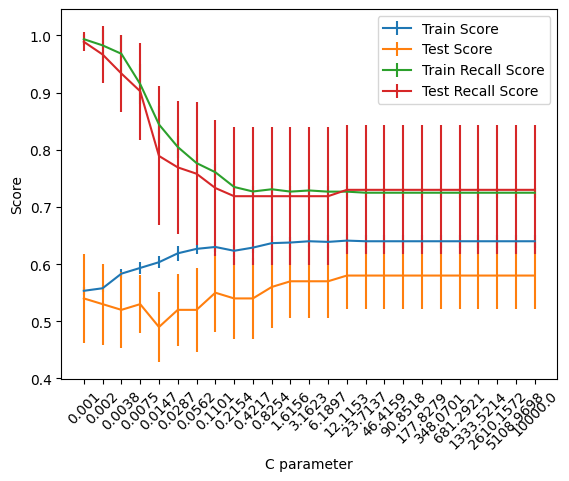

In [24]:
plt.errorbar(
    np.arange(len(lr_grid['param_C'])),
    lr_grid['mean_train_accuracy'],
    yerr=lr_grid['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(lr_grid['param_C'])),
    lr_grid['mean_test_accuracy'],
    yerr=lr_grid['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(lr_grid['param_C'])),
    lr_grid['mean_train_recall'],
    yerr=lr_grid['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(lr_grid['param_C'])),
    lr_grid['mean_test_recall'],
    yerr=lr_grid['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(lr_grid['param_C'])), round(lr_grid['param_C'], 4), rotation=45)
plt.xlabel('C parameter')
plt.ylabel('Score')
plt.legend()
plt.show()

In [27]:
lr_tuned = LogisticRegression(penalty='l2', random_state=seed, C=.0287).fit(X_train, y_train)

return_scores(lr_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.600000,0.781818,0.605634
Test,0.615385,0.857143,0.600000


## L1 Regularization

In [28]:
lr_2 = LogisticRegression(penalty='l1', solver='liblinear', random_state=seed)

lr_2.fit(X_train, y_train)

LogisticRegression(penalty='l1', random_state=5249, solver='liblinear')

In [29]:
return_scores(lr_2, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.59,0.763636,0.600000
Test,0.50,0.642857,0.529412


In [30]:
params = {
    'C': 10**np.linspace(-3,4,25)
}

grid = GridSearchCV(
    estimator=lr_2,
    param_grid=params,
    n_jobs=-1,
    cv=kfold,
    refit=False,
    scoring=['accuracy', 'recall'],
    return_train_score=True
)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
             estimator=LogisticRegression(penalty='l1', random_state=5249,
                                          solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 1.95734178e-03, 3.83118685e-03, 7.49894209e-03,
       1.46779927e-02, 2.87298483e-02, 5.62341325e-02, 1.10069417e-01,
       2.15443469e-01, 4.21696503e-01, 8.25404185e-01, 1.61559810e+00,
       3.16227766e+00, 6.18965819e+00, 1.21152766e+01, 2.37137371e+01,
       4.64158883e+01, 9.08517576e+01, 1.77827941e+02, 3.48070059e+02,
       6.81292069e+02, 1.33352143e+03, 2.61015722e+03, 5.10896977e+03,
       1.00000000e+04])},
             refit=False, return_train_score=True,
             scoring=['accuracy', 'recall'])

In [31]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.088890,0.054956,0.019285,0.008663,0.001000,{'C': 0.001},0.4,0.3,0.1,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.004098,0.001342,0.004982,0.000981,0.001957,{'C': 0.0019573417814876598},0.4,0.3,0.1,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.003857,0.001279,0.005468,0.001877,0.003831,{'C': 0.003831186849557289},0.4,0.3,0.1,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.006209,0.003357,0.007844,0.003973,0.007499,{'C': 0.007498942093324558},0.4,0.3,0.1,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.004175,0.001907,0.006118,0.004267,0.014678,{'C': 0.014677992676220698},0.4,0.3,0.1,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
grid_df.sort_values(by='param_C', ascending=True, inplace=True)

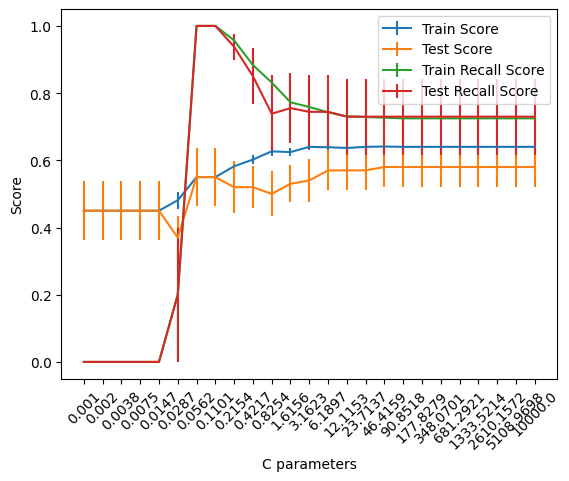

In [33]:
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_C'])), round(grid_df['param_C'], 4), rotation=45)
plt.xlabel('C parameters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [37]:
lr_2_tuned = LogisticRegression(
    C=.4217,
    # C=6.1897,
    solver='liblinear',
    penalty='l1',
    random_state=seed
    ).fit(X_train, y_train)

return_scores(lr_2_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.620000,0.909091,0.602410
Test,0.615385,0.928571,0.590909


In [38]:
coef_df = pd.DataFrame({
    'Coefficients': lr_2_tuned.coef_[0]
}, index=X_train.columns).sort_values('Coefficients', ascending=True)

coef_df

,Coefficients
I paid good price for my order,-0.245953
contents of my order was as I expected,0.000000
I ordered everything I wanted to order,0.000000
the app makes ordering easy,0.000000
my order was delivered on time,0.051681
I am satisfied with my courier,0.267268


We can interpret these coefficients by saying that given a satisfied customer there is a liklihood that over 30% ((1-exp(.267268))x100) of the time they will give a higher score on the question *I am satisified with my courier* than those unsatisfied customers and over a 5% higher score on the question *my order was delivered on time*.

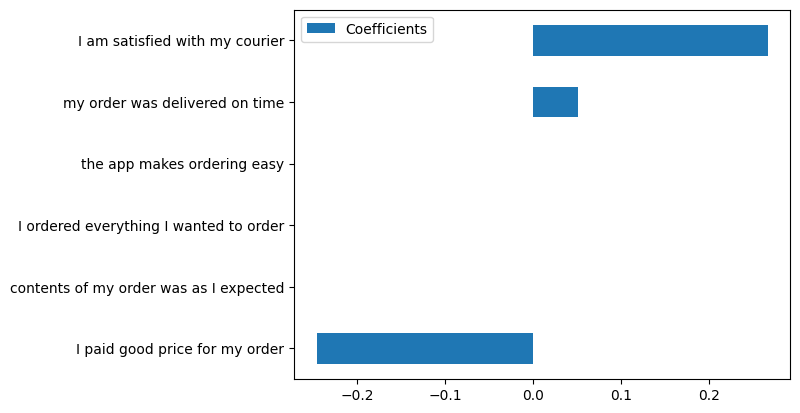

In [39]:
coef_df.plot(kind='barh')
plt.show()

In [72]:
import pathlib

path = pathlib.Path('../../feature importances/log_reg_coefs.csv')

if path.exists() != True:
    coef_df.to_csv(path)

In [40]:
pos_proba = lr_2_tuned.predict_proba(X_test)[:,1]

pos_sample = pos_proba[y_test==1]
neg_sample = pos_proba[y_test==0]

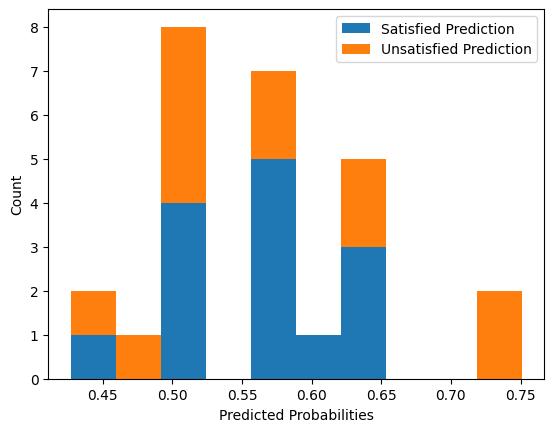

In [41]:
plt.hist([pos_sample, neg_sample], histtype='barstacked', label=['Satisfied Prediction', 'Unsatisfied Prediction'])
plt.xlabel('Predicted Probabilities')
plt.ylabel('Count')
plt.legend()
plt.show()

## Quadratic Discriminant Analysis

In [42]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

qda = QDA()

qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [43]:
return_scores(qda, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.700000,0.745455,0.719298
Test,0.538462,0.428571,0.600000


In [45]:
return_scores(lr_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.600000,0.781818,0.605634
Test,0.615385,0.857143,0.600000


In [44]:
return_scores(lr_2_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.620000,0.909091,0.602410
Test,0.615385,0.928571,0.590909


Comparing the Logistic Regression model using both L1 and L2 regularization with the QDA model we see: 
-  a more equal accuracy score in both the Logistic Regression models
-  a higher recall rate with the l2 normalized Logistic Regression model
-  more equal precision scores with both Logistic Regression models

Moving forward we will see if we can improve on the l2 normalization Logistic Regression model by using other models that are better at finding a non-linear boundary as well as finding possible interactions between predictors.

Look to svc.ipynb notebook next.